<p style="text-align:center">
    <a href="https://github.com/Vin-Okumu/marketminer-stock-scraper/blob/main/README.md" target="_blank">
    <img src="https://github.com/Vin-Okumu/marketminer-stock-scraper/blob/main/images/project_banner.png" width="200" alt="Web Scraping For Stock Data Analysis"  />
    </a>
</p>


<h1>Extracting and Visualizing Stock Data</h1>
<h2>Description</h2>


Extracting essential data from a dataset and displaying it is a necessary part of data science; therefore individuals can make correct decisions based on the data. In this assignment, the intention is to extract some stock data, which we will then display in a graph. specifcally, we will extract the most recent tesla and GameStop stock data as at June 30 2026. The idea is to learn how to perform simple web scrapoing using Beautiful Soup in Python.


<h2>Table of Contents</h2>
<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ul>
        <li>Define a Function that Makes a Graph</li>
        <li>Use yfinance to Extract Tesla and GameStop Stock Data</li>
        <li>Use Webscraping to Extract Tesla and GameStop Revenue Data</li>
        <li>Plot Tesla Stock and Revenue Graphs</li>
        <li>Plot GameStop Stock and Revenue Graphs</li>
    </ul>

</div>

<hr>


***Note***:- If you are working Locally using anaconda, please uncomment the following code and execute it.
Use the version as per your python version.


In [79]:
''''
!pip install yfinance
!pip install bs4
!pip install nbformat
!pip install matplotlib
'''

"'\n!pip install yfinance\n!pip install bs4\n!pip install nbformat\n!pip install matplotlib\n"

In [80]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup

In Python, you can ignore warnings using the warnings module. You can use the filterwarnings function to filter or ignore specific warning messages or categories.


In [81]:
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Defining Graphing Function


In this section, we define the function `make_graph`. **Without dwelling much on how the function works, and rather caring more about the inputs**, this function is intended to take a dataframe with stock data (dataframe containing Date and Close columns), a dataframe with revenue data (dataframe must contain Date and Revenue columns), and the name of the stock.


In [82]:
# The make_graph function has been modified to use Matplotlib for static graphs. 

import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2026-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2026-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

Using the make_graph function that we’ve already defined, we'll need to invoke it later in the notebook to display the graphs and create the dashboard. 
> **Note: It won't be necessary to redefine the function for plotting graphs anywhere else in this notebook.**


## Using yfinance to Extract Respective Stock Market Data


Here we'll use the `Ticker` function together with the symbol of the stock we want to extract data on to create a ticker object. The first stock is Tesla and its ticker symbol is `TSLA`, and the second is GameStop and its ticker symbol is `GME`


### Tesla Stock Market Data

In [83]:
# Extracting Tesla stock data
tesla = yf.Ticker("TSLA")

# Extracting GameStop stock data
gamestop = yf.Ticker('GME')


Using the ticker object and the function `history` we'll extract stock information in this section and save them in dataframes named `tesla_data` and `gme_data` for tesla and gamestop respectively. We'll set the `period` parameter to ` "max" ` so we get information for the maximum amount of time.


In [84]:
# Saving extracted tesla data into tesla_data dataframe
tesla_data = tesla.history(period='max')

# Saving extracted gamestop data into gme_data dataframe
gme_data = gamestop.history(period = 'max')

In this section we **Reset the index** using the `reset_index(inplace=True)` function on both DataFrames and display the first five rows of each `dataframe` using the `head` function and the last five rows using the `tail` function. 

In [85]:
tesla_data.reset_index(inplace=True)
first_five_tesla = tesla_data.head()
last_five_tesla = tesla_data.tail()

print('First 5 Records')
display(first_five_tesla)

print('Last 5 Records')
display(last_five_tesla)

First 5 Records


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


Last 5 Records


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
4020,2026-06-24 00:00:00-04:00,380.079987,384.579987,373.049988,375.529999,37081400,0.0,0.0
4021,2026-06-25 00:00:00-04:00,375.269989,379.119995,371.220001,375.119995,30138800,0.0,0.0
4022,2026-06-26 00:00:00-04:00,370.149994,387.799988,368.600006,379.709991,53434100,0.0,0.0
4023,2026-06-29 00:00:00-04:00,381.790009,413.269989,379.299988,411.839996,57645800,0.0,0.0
4024,2026-06-30 00:00:00-04:00,406.000000,424.540009,406.000000,420.600006,43068300,0.0,0.0


In [86]:
# Save the first 100 rows as sample data
sample_tesla_df = tesla_data.head(100)

sample_tesla_df.to_csv(
    "../data/sample_data/yfinance_tesla_df.csv",
    index = False
    )

### GameStop Stock Market Data

In [ ]:
# Extracting GameStop stock market data

gme_data.reset_index(inplace=True)
first_five_gme = gme_data.head()
last_five_gme = gme_data.tail()

print('First 5 Records')
display(first_five_gme)

print('Last 5 Records')
display(last_five_gme)

First 5 Records


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693349,1.603295,1.691666,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712708,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0


Last 5 Records


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
6128,2026-06-24 00:00:00-04:00,21.180000,21.65,21.170000,21.440001,3354300,0.0,0.0
6129,2026-06-25 00:00:00-04:00,21.360001,21.41,20.930000,21.010000,3820400,0.0,0.0
6130,2026-06-26 00:00:00-04:00,20.940001,21.85,20.940001,21.760000,5703100,0.0,0.0
6131,2026-06-29 00:00:00-04:00,22.049999,22.15,21.879999,22.030001,4060300,0.0,0.0
6132,2026-06-30 00:00:00-04:00,21.850000,22.18,21.700001,22.080000,4344800,0.0,0.0


In [ ]:
# Saving the first 100 rows as sample GameStop data

sample_gme_df = gme_data.head(100)

sample_gme_df.to_csv(
    "../data/sample_data/yfinance_gamestop_df.csv",
    index = False
    )

## Using Webscraping to Extract TSLA Revenue Data


Here we use the `requests` library to download the webpage https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue.

The `response_t.status_code` of 200 implies the script's HTTP request to the targeted server was completely successful at the protocol level. 

It means the server received, understood and successfully processed our request and has sent back the tesla data we have asked for i.e the HTML source code of the webpage


In [89]:
url_tes = 'https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue'
headers_1 = {'User-Agent':'Mozilla/5.0'}
response_t = requests.get(url_tes, headers = headers_1)
print(response_t.status_code)

200


In this section, we parse the html data using `beautiful_soup` using parser i.e `html.parser`.


In [90]:
beautiful_soup_1 = BeautifulSoup(response_t.text,'html.parser')
tables = beautiful_soup_1.find_all("table")

Following the web inspection we conducted in the notebook *web_inspect_tesla.ipynb* we now know that the tesla revenue data we are interested in is in the second table i.e `('table')[1]`.

Therefore, when extracting the revenue data table, we'll call `('table')[1]`, thereby eliminating guesswork.

In [91]:
table_tesla = beautiful_soup_1.find_all('table')[1]

tbody = table_tesla.find('tbody')

data = []
    
for row in tbody.find_all('tr'):
        col = row.find_all('td')
        
        data.append({
            'Date' : col[0].text.strip(),
            'Revenue' : col[1].text.strip()
        })
        
        tesla_revenue = pd.DataFrame(data)
tesla_revenue.head()

,Date,Revenue
0,2026-03-31,"$22,387"
1,2025-12-31,"$24,901"
2,2025-09-30,"$28,095"
3,2025-06-30,"$22,496"
4,2025-03-31,"$19,335"


Here we'll use `BeautifulSoup` function to extract the table with `Tesla Revenue` and store it into a dataframe named `tesla_revenue`. The dataframe should have columns `Date` and `Revenue`.



In this section , we remove the comma and dollar sign as well as the null or empty string from the `Revenue` column. And display the first and last five rows using the `head` and `tail` functions respectively


In [92]:
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(r',|\$',"",regex=True)

tesla_revenue.dropna(inplace=True)

tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

tesla_revenue.head()

,Date,Revenue
0,2026-03-31,22387
1,2025-12-31,24901
2,2025-09-30,28095
3,2025-06-30,22496
4,2025-03-31,19335


## Using Webscraping to Extract GME Revenue Data


In this section we'll use the `requests` library to download the webpage https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue.

Again, the `response_g.status_code` of 200 implies the script's HTTP request to the targeted server was completely successful at the protocol level. 

It means the server received, understood and successfully processed our request and has sent back the GameStop data we have asked for i.e the HTML source code of the webpage

In [93]:
url_gme = 'https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue'
headers_2 = {'User-Agent':'Mozilla/5.0'}
response_g = requests.get(url_gme, headers = headers_2)
print(response_g.status_code)

200


Again, we parse the html data using `beautiful_soup_2` using parser i.e `html.parser`. 

Since the code is being run in the same notebook, following the code to extract tesla data, it's important that we don't name our objects the same as the objects we used to extract the tesla data, lest we call the wrong data.


In [94]:
beautiful_soup_2 = BeautifulSoup(response_g.text,'html.parser')
tables = beautiful_soup_2.find_all("table")

In this section, we'll use `BeautifulSoup` function extract the table with `GameStop Revenue` and store it into a dataframe named `gme_revenue`. The dataframe should have columns `Date` and `Revenue`. Make sure the comma and dollar sign is removed from the `Revenue` column.


In [95]:
table_gme = beautiful_soup_2.find_all('table')[1]

tbody = table_gme.find('tbody')

data = []
    
for row in tbody.find_all('tr'):
        col = row.find_all('td')
        
        data.append({
            'Date' : col[0].text.strip(),
            'Revenue' : col[1].text.strip()
        })
        
        gme_revenue = pd.DataFrame(data)
gme_revenue.head()

,Date,Revenue
0,2026-04-30,$835
1,2026-01-31,"$1,104"
2,2025-10-31,$821
3,2025-07-31,$972
4,2025-04-30,$732


We'll remove the comma and dollar sign from the records.

Also we'll remove null or empty strings from the Revenue column.


In [96]:
gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(r',|\$',"",regex=True)

gme_revenue.dropna(inplace=True)

gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]

gme_revenue.head()

,Date,Revenue
0,2026-04-30,835
1,2026-01-31,1104
2,2025-10-31,821
3,2025-07-31,972
4,2025-04-30,732


## Plotting Tesla Stock Graph


Use the `make_graph` function to graph the Tesla Stock Data, also provide a title for the graph. Note the graph will only show data upto June 2021.


<details><summary>Hint</summary>

```

You just need to invoke the make_graph function with the required parameter to print the graphs.The structure to call the `make_graph` function is `make_graph(tesla_data, tesla_revenue, 'Tesla')`.

```
    
</details>


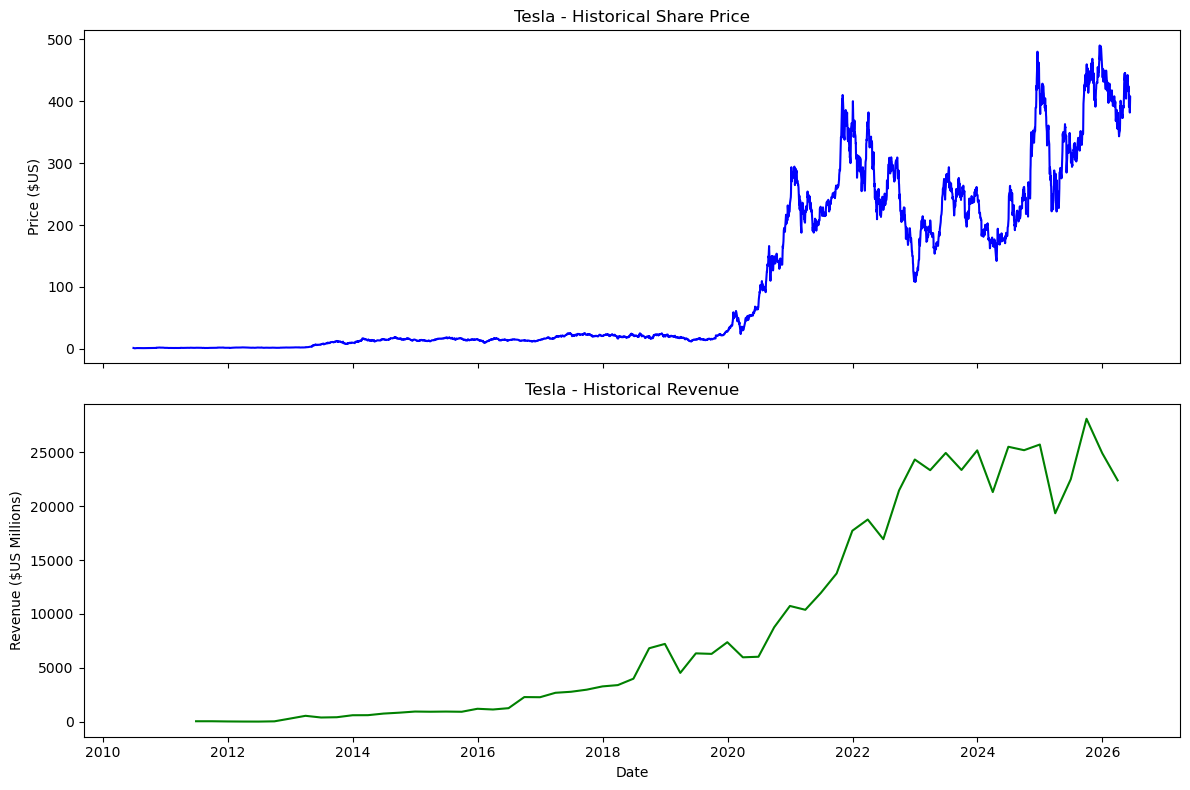

In [34]:
make_graph(tesla_data, tesla_revenue, 'Tesla')

## Plotting GameStop Stock Graph


Use the `make_graph` function to graph the GameStop Stock Data, also provide a title for the graph. The structure to call the `make_graph` function is `make_graph(gme_data, gme_revenue, 'GameStop')`. Note the graph will only show data upto June 2021.


<details><summary>Hint</summary>

```

You just need to invoke the make_graph function with the required parameter to print the graphs.The structure to call the `make_graph` function is `make_graph(gme_data, gme_revenue, 'GameStop')`

```
    
</details>


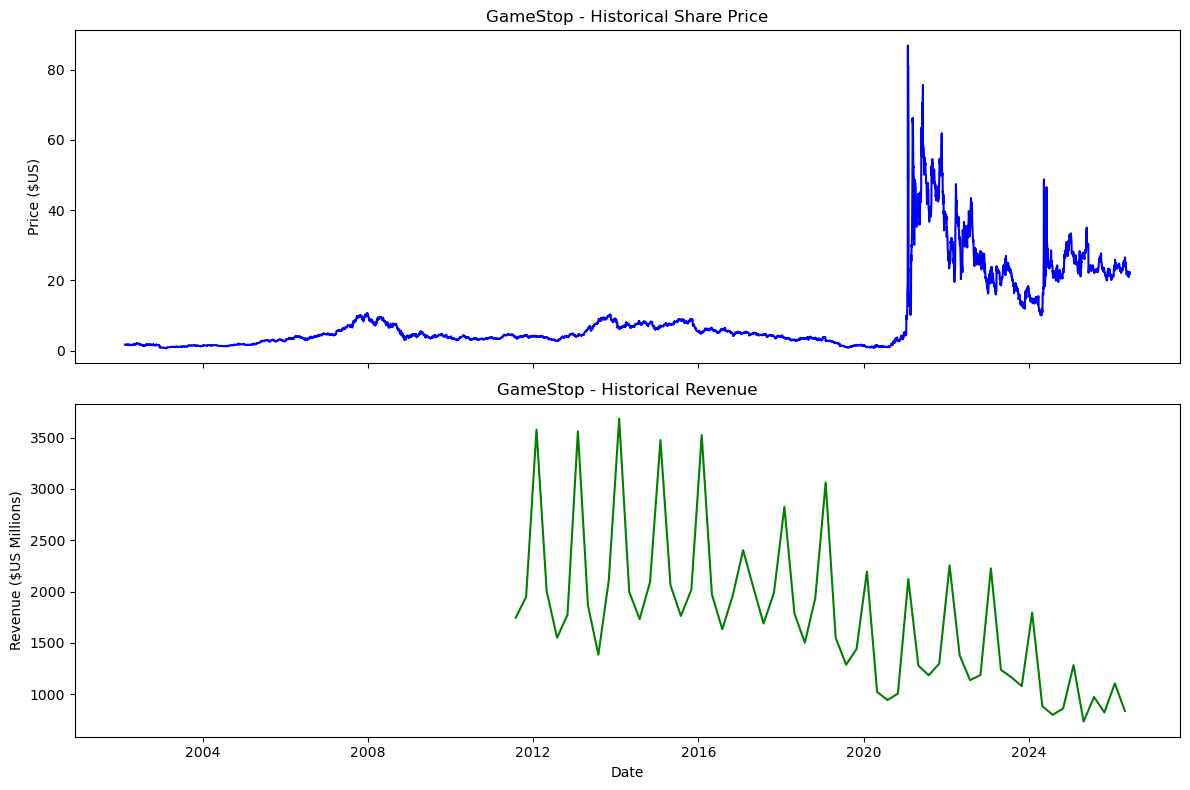

In [35]:
make_graph(gme_data, gme_revenue, 'GameStop')